In [1]:
import pandas as pd
import xarray as xr
import numpy as np
import glob as glob

import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import ScalarFormatter

# Aim: Compare model profile with CTD profile 
- Comparing temperature 


# Load MITgcm data 

In [2]:
def load_data(run, output, var):

    # Change your path accordingly 
    path_in = "/Users/ramajem/Documents/mitgcm/archive/collated_out/{}/{}/".format(run,output)
    fname_data = glob.glob(path_in + var + "*.nc")

    data = xr.open_mfdataset(fname_data, chunks={'X':8,'Y':16}).squeeze()
    data = data.sortby('T').drop_duplicates(dim='T')

    return (data)

In [3]:
run = 'nov2025_zug120'
output = '*' #or out1, out2,.. 

temp_mit = load_data(run, output, "theta").Temp


# Load CTD data 
- Change path to your own data path
- Profile should already be cut to downwcast 
- netcdf of CTD data should also contain coordinates of sampling location 

In [21]:
date = '20260319'
ctd_name = '*.nc'
path_ctd = "/Users/ramajem/Documents/zug_observation/data/APhys/CTD/{}/L1/datalakes/".format(date)

In [22]:
fname_ctd = glob.glob(path_ctd + ctd_name)[0] #or add a code to extract a specific ctd profile 
ctd = xr.open_dataset(fname_ctd)

# EXtract temperature and assign depth 
temp = ctd.Temp 
depth = ctd.Press.values
temp_ctd = temp.rename({"time":"Z"}).assign_coords(Z=-depth)

# Extract some attributes
time_ctd = ctd["time"][0]
lat_ctd = ctd.attrs["latitude"]
lon_ctd = ctd.attrs["longitude"]
xch_ctd =  int(ctd.attrs["X Coordinate (CH1903)"])
ych_ctd = int(ctd.attrs["Y Coordinate (CH1903)"])

stn_num = ctd.attrs["Profile name"]


# Transform coordinates into model location 
- Coordinates in CTD metadata are usually saved in WGS84 (some newer profiles are already in swiss coordinates)

In [24]:
def LatLonToSwissGrid(latitude, longitude):
    '''
    Convert a (longitude, latitude) point to the Swiss coordinate system,
    in accordance with the formulas given in 'Approximate formulas for the
    transformation between Swiss projection coordinates and WGS84'.
    '''

    phiPrime = (3600*latitude - 169028.66) / 10000
    lamPrime = (3600*longitude - 26782.5) / 10000
    xCoord = ( 600072.37 +
               211455.93 * lamPrime -
               10938.51  * lamPrime*phiPrime -
               0.36      * lamPrime*phiPrime**2 -
               44.54     * lamPrime**3 )
    yCoord = ( 200147.07 +
               308807.95 * phiPrime +
               3745.25   * lamPrime**2 +
               76.63     * phiPrime**2 -
               194.56    * phiPrime*lamPrime**2 +
               119.79    * phiPrime**3 )

    return (xCoord, yCoord)

In [25]:
x_ctd, y_ctd = LatLonToSwissGrid(lat_ctd, lon_ctd)

# point of origin in swiss grid 
XO_SG = 676648
YO_SG = 212416

# convert to coordinates on the grid 
xmit_ctd  =  int(x_ctd) - XO_SG
ymit_ctd = int(y_ctd) - YO_SG

print('xcoord on model:{}'.format(xmit_ctd ))
print('ycoord on model:{}'.format(ymit_ctd ))

xcoord on model:3562
ycoord on model:5717


## Plot ctd location on model grid 

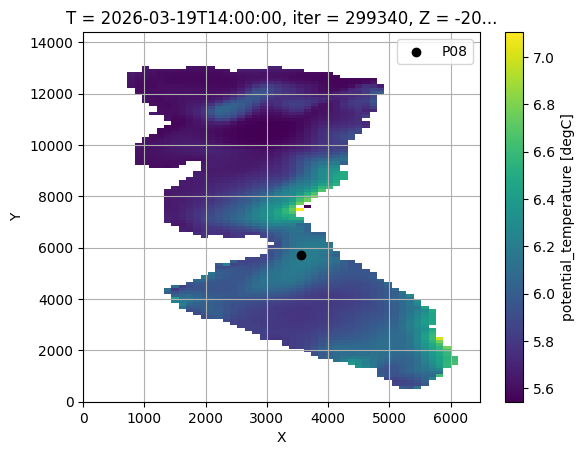

In [27]:
temp_mit.sel(T=time_ctd,Z=-20, method="nearest").plot()
plt.scatter(xmit_ctd, ymit_ctd, color="k",label='{}'.format(stn_num))
plt.legend()
plt.grid()


# Extract model temperature at CTD location 

In [28]:
temp_mitxy = temp_mit.sel(X=xmit_ctd,Y=ymit_ctd,T=time_ctd, method='nearest')


# Plot temperature (model vs CTD)

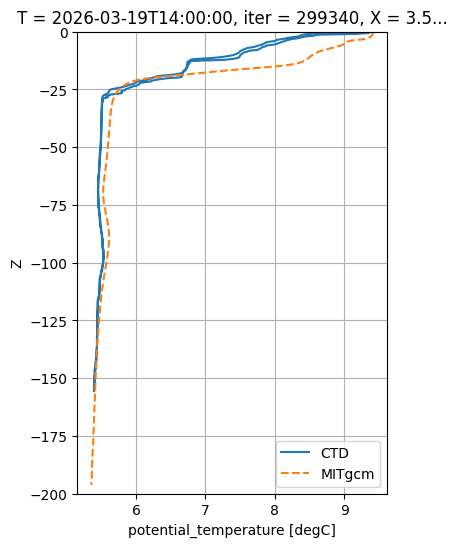

In [29]:
fig, ax = plt.subplots(1,figsize=(4, 6))

temp_ctd.plot(y="Z",label="CTD")
temp_mitxy.plot(linestyle="--",y="Z",label="MITgcm")
plt.legend()
plt.ylim(-200,0)
plt.grid()
